In [4]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

In [3]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model(model_provider="groq",model = "llama-3.1-8b-instant",temperature=1)


In [5]:
docs = DirectoryLoader(r"C:\Users\mendh\Langchain-Langgraph\0-Dataingestion-parsing\data\text_files",loader_cls=TextLoader).load()
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = splitter.split_documents(docs)
vectorstore = FAISS.from_documents(chunks,embedding=embeddings)
retriever = vectorstore.as_retriever()

C:\Users\mendh\AppData\Local\Temp\ipykernel_22408\3697250630.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
class IterativeRAGState(BaseModel):
    question: str
    refined_question: str = ""
    retrieved_docs: List[Document] = []
    answer: str = ""
    verified: bool = False
    attempts: int = 0

In [7]:
def reflect_on_answer(state: IterativeRAGState):

    prompt = f""" Evaluate whether the answer below is factually sufficient and complete.

    question: {state.question}
    Answer: {state.answer}

Respond 'YES' if it's complete, otherwise 'NO' with feedback

"""
    feedback = llm.invoke(prompt).content.lower()
    verified = "yes" in feedback
    return state.model_copy(update={"verified":verified})

In [8]:
def refine_query(state: IterativeRAGState):
    prompt = f""" The answer appers incomplete. Suggest a better version of the query that would help retrieve more relevant context.

    Original Question: {state.question}
    Current Answer: {state.answer}
"""
    
    new_query = llm.invoke(prompt).content.strip()

    return state.model_copy(update={"refined_question":new_query})

In [9]:
def retrieve_docs(state:IterativeRAGState):
    query = state.refined_question or state.question
    docs = retriever.invoke(query)
    return state.model_copy(update={"retrieved_docs":docs})

In [10]:
def generate_answer(state:IterativeRAGState):
    context = "\n\n".join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""Use the following context to answer the question:

    Context:{context}
    Question: {state.question}

"""
    response = llm.invoke(prompt.strip()).content.strip()

    return state.model_copy(update={"answer":response, "attempts": state.attempts+1})

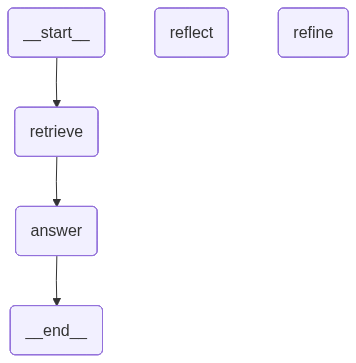

In [11]:
builder = StateGraph(IterativeRAGState)

builder.add_node("retrieve",retrieve_docs)
builder.add_node("answer",generate_answer)
builder.add_node("reflect", reflect_on_answer)
builder.add_node("refine",refine_query)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve","answer")
builder.add_conditional_edges(
    "reflect",
    lambda s: END if s.verified or s.attempts>=2 else "refine"
)
builder.add_edge("refine","retrieve")
builder.add_edge("answer",END)

graph = builder.compile()
graph

In [21]:
intial_state = IterativeRAGState(question="Types of ML algos ")
response = graph.invoke(intial_state)

print("Final Answer:\n\n", response["answer"])
print("Verified:", response["verified"])
print("Attempts:\n", response["attempts"])

Final Answer:

 Based on the context provided, there are three main types of Machine Learning (ML) algorithms mentioned:

1. **Supervised Learning Algorithms**:
   * Objectives: Classification and regression
   * This type of algorithm learns from labeled data to make predictions or classify new data.

2. **Unsupervised Learning Algorithms**:
   * Objectives: Clustering, dimensionality reduction, and association rule
   * This type of algorithm works on unlabeled data to discover patterns or relationships within the data.

3. **Reinforcement Learning Algorithms**:
   * Objectives: Decisions made with respect to some previous, unknown time
   * This type of algorithm can be divided into two subcategories: model-based methods and model-free methods.
Verified: False
Attempts:
 1
